In [1]:
%load_ext autoreload
%autoreload 2

from algo_align_research_utils.paths import get_project_root_str

project_root = get_project_root_str()
project_root


'c:/Users/omers/CodeProjects/learning-tsp'

In [2]:
import os
import numpy as np
import pandas as pd
import pickle
import json
from os import path
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

os.makedirs('results/img/', exist_ok=True)
np.random.seed(1234)

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

# Dict to format names for display
format_name = {
    # Search settings
    'greedy': "Greedy Search",
    'bs128': "Beam Search (width=128)",
    'bs512': "Beam Search (width=512)",
    'bs1280': "Beam Search (width=1280)",
    'sample128': "Sampling (128 soln.)",
    'sample512': "Sampling (512 soln.)",
    'sample1280': "Sampling (1280 soln.)",
}

def opts_to_df(opts_list, addn_col_name="Additional", add_concorde=False, add_heuristic=False):
    plot = {
        "TSP Size": [],
        "Model": [],
        "Search Setting": [],
        "GT Tour Length": [],
        "Predicted Tour Length": [],
        "Optimality Gap (%)": [],
        "Evaluation Time": [],
        "Additional": []  # for any additional information
    }

    for opts in opts_list:
        for model, name, addn in zip(opts.models, opts.names, opts.addn):
            dataset_basename, ext = os.path.splitext(os.path.split(opts.dataset)[-1])
            model_name = "_".join(os.path.normpath(os.path.splitext(model)[0]).split(os.sep)[-2:])
            results_dir = os.path.join(project_root, 'results', dataset_basename)
            out_file = os.path.join(results_dir, "{}-{}-{}{}-t1-{}-{}{}.pkl".format(
                dataset_basename, model_name,
                opts.decode_strategy,
                opts.width if opts.decode_strategy != 'greedy' else '',
                opts.offset, opts.offset + opts.val_size, ext
            ))

            results = pickle.load(open(out_file, 'rb'))
            costs, gt_costs, tours, gt_tours, opt_gap, durations = zip(*results)
            num_nodes = ([len(tour) for tour in tours])

            plot["TSP Size"] += num_nodes
            plot["Model"] += ([name]*len(tours))
            plot["Search Setting"] += ([format_name[opts.decode_strategy+str(opts.width) if opts.decode_strategy!='greedy' else 'greedy']]*len(tours))
            plot["GT Tour Length"] += gt_costs
            plot["Predicted Tour Length"] += costs
            plot["Optimality Gap (%)"] += opt_gap
            plot["Evaluation Time"] += durations
            plot["Additional"] += ([addn]*len(tours))
            
    if add_concorde:
        plot["TSP Size"] += num_nodes
        plot["Model"] += (["Concorde"]*len(tours))
        plot["Search Setting"] += (["None"]*len(tours))
        plot["GT Tour Length"] += gt_costs
        plot["Predicted Tour Length"] += gt_costs
        plot["Optimality Gap (%)"] += ([0.0]*len(tours))
        plot["Evaluation Time"] += ([0.0]*len(tours))
        plot["Additional"] += (["Concorde"]*len(tours))
        
    if add_heuristic:
        dataset_basename, ext = os.path.splitext(os.path.split(opts.dataset)[-1])
        results_dir = os.path.join(project_root, 'results', dataset_basename)
        out_file = os.path.join(results_dir, "{}n{}-farthest_insertion{}.pkl".format(
                dataset_basename, opts.val_size, ext
            ))
        results = pickle.load(open(out_file, 'rb'))
        costs, gt_costs, tours, gt_tours, opt_gap, durations = zip(*results)
        num_nodes = ([len(tour) for tour in tours])

        plot["TSP Size"] += num_nodes
        plot["Model"] += (["Insertion Heuristic"]*len(tours))
        plot["Search Setting"] += (["Greedy Search"]*len(tours))
        plot["GT Tour Length"] += gt_costs
        plot["Predicted Tour Length"] += costs
        plot["Optimality Gap (%)"] += opt_gap
        plot["Evaluation Time"] += durations
        plot["Additional"] += (["Insertion Heuristic"]*len(tours))
        
    # Convert to dataframe
    df_plot = pd.DataFrame.from_dict(plot)
    # Rename additional column
    df_plot.columns = list(df_plot.columns[:-1]) + [addn_col_name]
    return df_plot

C:\Users\omers\AppData\Local\Temp\ipykernel_52232\1896693884.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 99)` for the same effect.

  ax = sns.lineplot(x="TSP Size", y="Optimality Gap (%)",


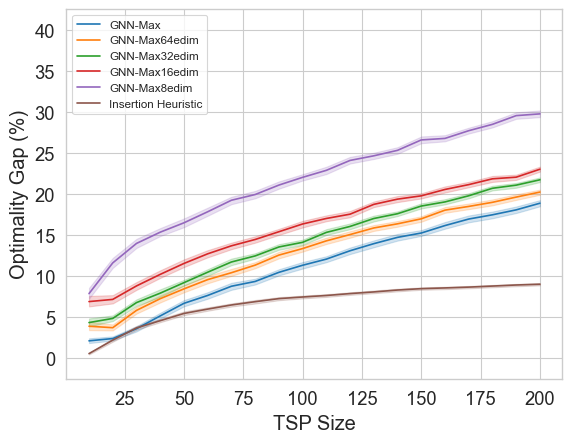

C:\Users\omers\AppData\Local\Temp\ipykernel_52232\1896693884.py:57: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 99)` for the same effect.

  ax = sns.lineplot(x="TSP Size", y="Optimality Gap (%)",


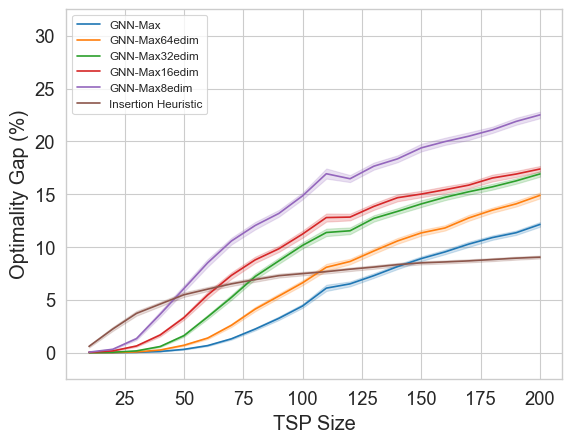

In [3]:
class opts1:
    models = [
        path.join(project_root, 'outputs/tspsl_20-50/sl-ar-var-20pnn-gnn-max_20200308T172931'),
        path.join(project_root, "outputs/tspsl_20-50/sl-ar-var-20pnn-64edim-gnn-max_20250808T010107"),
        path.join(project_root, "outputs/tspsl_20-50/sl-ar-var-20pnn-32edim-gnn-max_20250808T104211"),
        path.join(project_root, "outputs/tspsl_20-50/sl-ar-var-20pnn-16edim-gnn-max_20250808T151845"),
        path.join(project_root, "outputs/tspsl_20-50/sl-ar-var-20pnn-8edim-gnn-max_20250808T220639"),
    ]
    names = [
        'GNN-Max',
        'GNN-Max64edim',
        'GNN-Max32edim',
        'GNN-Max16edim',
        'GNN-Max8edim',
    ]
    addn = names
    dataset = path.join(project_root, "data/tsp/tsp10-200_concorde.txt")
    decode_strategy = 'greedy'
    width = 0
    offset = 0
    val_size = 25600
    
class opts2:
    models = [
        path.join(project_root, 'outputs/tspsl_20-50/sl-ar-var-20pnn-gnn-max_20200308T172931'),
        path.join(project_root, "outputs/tspsl_20-50/sl-ar-var-20pnn-64edim-gnn-max_20250808T010107"),
        path.join(project_root, "outputs/tspsl_20-50/sl-ar-var-20pnn-32edim-gnn-max_20250808T104211"),
        path.join(project_root, "outputs/tspsl_20-50/sl-ar-var-20pnn-16edim-gnn-max_20250808T151845"),
        path.join(project_root, "outputs/tspsl_20-50/sl-ar-var-20pnn-8edim-gnn-max_20250808T220639"),
    ]
    names = [
        'GNN-Max',
        'GNN-Max64edim',
        'GNN-Max32edim',
        'GNN-Max16edim',
        'GNN-Max8edim',
    ]
    addn = names
    dataset = path.join(project_root, "data/tsp/tsp10-200_concorde.txt")
    decode_strategy = 'bs'
    width = 128
    offset = 0
    val_size = 25600

    
ax = sns.lineplot(x="TSP Size", y="Optimality Gap (%)", 
                  hue="Training Size", # style="Model", # palette=["r", "g", "b"],
                  ci=99, err_style='band',
                  data=opts_to_df([opts1], addn_col_name='Training Size', add_heuristic=True)
)
ax.legend(loc=2, fontsize='xx-small')
ax.set(ylim=(-2.5, 42.5))
# ax.set_title("Fixed vs. variable sized TSP instances (Greedy search)")
ax.get_figure().savefig("results/img/fixed_vs_var-sl-ar-full-gnn_max-greedy.pdf", format='pdf', dpi=1200, bbox_inches='tight')
plt.show()

ax = sns.lineplot(x="TSP Size", y="Optimality Gap (%)", 
                  hue="Training Size", # style="Model", # palette=["r", "g", "b"],
                  ci=99, err_style='band',
                  
                  data=opts_to_df([opts2], addn_col_name='Training Size', add_heuristic=True)
)
ax.legend(loc=2, fontsize='xx-small')
ax.set(ylim=(-2.5, 32.5))
# ax.set_title("Fixed vs. variable sized TSP instances (Beam search, width=128)")
ax.get_figure().savefig("results/img/fixed_vs_var-sl-ar-full-gnn_max-bs128.pdf", format='pdf', dpi=1200, bbox_inches='tight')
plt.show()